# 실험 13 — 선수 피처 제거와 과거 연도 학습

## 결정과 요약

- 2025년 검증으로 고정한 피처 후보: `without_past_xpdiffat15`. 제거: 15분 경험치 차이.
- 2025년 검증으로 선택한 전체 구성: **reduced_2023_2024_2025**.
- 선택 구성의 2026년 회고 평가: **115/186 = 61.83%**, log loss 0.6776.
- 기존 A 기준은 118/186 = 63.44%. 아래 2026 결과에서 최고값을 골라 선택 결정을 바꾸지 않았다.
- 현재 연구 기준은 기존 LCK-only 13피처 A로 유지한다. 2025에서 정한 새 후보가 이를 대체할 근거를 얻지 못했다.
- 온라인 배포와 기존 모델 파일은 변경하지 않았다.

## 비교 설계

1. LCK-only A 구조, 3 seed 확률 앙상블, Adam .001, 최대500/patience30 유지.
2. 2025년 날짜의 앞40%로 시작하는 세 개 expanding-window fold: 40→60%, 60→80%, 80→100%. 총123시리즈. 각 fold의 학습 구간 내부 마지막20% 날짜에서 epoch를 정한 뒤 해당 학습 구간 전체로 재학습했다. 외부 평가 구간은 epoch 선택에 사용하지 않았다.
3. 13개 피처를 하나씩 제거해 실제 재학습했다. 나머지 초기 가중치는 동일하게 유지했다. 정확도와 log loss가 모두 좋아진 피처가 둘 이상이면 상위 최대3개를 동시에 제거하는 후보도 시험했다. 전체13개도 후보로 남겼다.
4. 피처를 먼저 고정하고, 전체13개와 축소 입력 각각에서 2025 / 2024~2025 / 2023~2025를 비교했다. 정확도를 우선하고 동점에서 log loss로 선택했다.
5. 최종 epoch는 기존과 같은2025 마지막33시리즈로 정하고, 해당 연도 전체로 재학습했다. 피처·연도·epoch·가중치를 저장한 뒤2026을 로드했다.

검증 기간: 2025-05-04 06:06:00 ~ 2025-09-28 05:30:31.
회고 평가 기간: 2026-01-14 08:13:43 ~ 2026-09-12 05:21:16.

## 선수 피처를 하나씩 제거한 결과 — 2025년 검증

| 제거한 피처 | 정답 | 정확도 | 기준 대비 정답 | Log loss | 개선 구간 수 |
| --- | --- | --- | --- | --- | --- |
| 15분 경험치 차이 | 81/123 | 65.85% | +2 | 0.6480 | 1/3 |
| CSPM | 80/123 | 65.04% | +1 | 0.6500 | 1/3 |
| DPM | 79/123 | 64.23% | +0 | 0.6432 | 1/3 |
| 삭제 없음 (13개) | 79/123 | 64.23% | +0 | 0.6607 | 0/3 |
| 피해 점유율 | 78/123 | 63.41% | -1 | 0.6330 | 1/3 |
| 획득 골드 점유율 | 78/123 | 63.41% | -1 | 0.6502 | 0/3 |
| 유리했던 피처 동시 제거 | 78/123 | 63.41% | -1 | 0.6670 | 1/3 |
| 분당 데스 | 77/123 | 62.60% | -2 | 0.6646 | 2/3 |
| 15분 골드 차이 | 76/123 | 61.79% | -3 | 0.6487 | 1/3 |
| 분당 킬 | 76/123 | 61.79% | -3 | 0.6531 | 0/3 |
| 15분 CS 차이 | 75/123 | 60.98% | -4 | 0.6526 | 0/3 |
| 분당 어시스트 | 74/123 | 60.16% | -5 | 0.6458 | 1/3 |
| 최근 승률 | 74/123 | 60.16% | -5 | 0.6763 | 0/3 |
| 분당 시야 점수 | 73/123 | 59.35% | -6 | 0.6790 | 0/3 |
| 기록량 | 73/123 | 59.35% | -6 | 0.6803 | 0/3 |

양수는 해당 피처를 빼고 다시 학습했을 때 더 맞힌 시리즈 수다. 이것은 해당 통계가 본질적으로 해롭다는 뜻이 아니다. 피처 중복, 작은 표본, 최적화와 모델 용량 변화가 함께 작용한다. 세 구간의 일관성도 함께 봐야 한다. 이 표를 보고 후보를 선택했으므로 선택된 검증 점수에는 선택 편향이 있다.

이번에는 XP 차이 제거(+2)와 CSPM 제거(+1)가 각각 세 구간 중 한 구간에서만 개선됐다. 둘을 함께 제거하면 오히려78/123으로 낮아졌다. 따라서 두 피처를 확실히 해로운 피처로 분류할 수 없다. 시야 점수와 기록량 제거는 각각6개, 승률 제거는5개를 덜 맞혔다.

## 과거 데이터 품질과 통제

- 2023 LCK 488세트 중15분 골드/XP/CS 통계가 없는1세트를 제외해487세트 사용.
- 2024 LCK 482세트 사용. 2025 LCK 555세트 유지.
- 학습 표본 수: 555 → 1,037 → 1,524세트. 모두 동일한 세트 가중치.
- 2025·2026 입력은 기존 A와 완전히 동일하다. 2023·2024는 각각 해당 연도 내부의 과거 기록으로 피처를 생성했다. 따라서 이번 실험은 오래된 학습 표본 추가 효과를 본다. 2024 기록으로2025 시즌 초 입력을 보강하는 효과는 시험하지 않았다.
- 리그 확대, 선수 ID embedding, 밴픽, 시간 가중치, fine-tuning은 추가하지 않았다.

## 학습 연도 비교 — 2025년 검증 및 선택

`all13`은 기존13피처, `reduced`는 위에서 고정한 축소 피처다.

| 구성 | 정답 | 정확도 | Log loss | AUC |
| --- | --- | --- | --- | --- |
| all13_2025 | 79/123 | 64.23% | 0.6607 | 0.6706 |
| all13_2024_2025 | 79/123 | 64.23% | 0.6276 | 0.7010 |
| all13_2023_2024_2025 | 79/123 | 64.23% | 0.6299 | 0.6919 |
| reduced_2025 | 81/123 | 65.85% | 0.6480 | 0.6892 |
| reduced_2024_2025 | 78/123 | 63.41% | 0.6282 | 0.6900 |
| reduced_2023_2024_2025 | 81/123 | 65.85% | 0.6262 | 0.6890 |

## 고정된 구성의 2026년 회고 평가

| 구성 | 정답 | 정확도 | Log loss | AUC |
| --- | --- | --- | --- | --- |
| all13_2025 | 118/186 | 63.44% | 0.6754 | 0.6484 |
| all13_2024_2025 | 112/186 | 60.22% | 0.6793 | 0.6406 |
| all13_2023_2024_2025 | 110/186 | 59.14% | 0.6811 | 0.6358 |
| reduced_2025 | 106/186 | 56.99% | 0.6688 | 0.6427 |
| reduced_2024_2025 | 109/186 | 58.60% | 0.6718 | 0.6392 |
| reduced_2023_2024_2025 | 115/186 | 61.83% | 0.6776 | 0.6463 |

2026년은 이전 연구에서 여러 번 살펴본 자료다. 독립된 새 테스트가 아니다. 2025년 검증으로 선택한 구성은 `reduced_2023_2024_2025`이며, 2026년 최고 점수와 구분한다. 정확도와 log loss가 다른 방향으로 움직이면 어느 지표가 개선됐는지 구분해야 한다.

13피처에서는 과거 연도를 더할수록118→112→110개로 정확도가 낮아졌다. XP를 뺀12피처에서는106→109→115개로 개선됐지만 기존 A보다3개 적었다. 반면12피처/2025의 log loss는0.6688로 기존0.6754보다 낮았다. 과거 데이터가 항상 해롭다거나 피처 축소가 모든 지표에서 실패했다고 일반화할 수 없다. 이번의 동일 가중치 혼합 방식으로는 기준 정확도를 넘지 못했다.

`paired_comparison.csv`는 기존 A와 비교해 새로 맞히거나 놓친 시리즈 수를 기록한다. `paired_bootstrap_2026.csv`는 시리즈별 정답 차이를 10,000회 재표집한 기술적95% 구간이다. 경기 사이의 의존성이나 반복적인 모델 선택은 반영하지 않으므로 확정적인 유의성 검정으로 해석하지 않는다.

## 검증과 재현

- 기존 all13/2025 예측을 실험10과 확률 오차1e-6 이내로 재현.
- 2026 추가 시2025 입력 불변, 팀 순서 반전 대칭, 평가 전 선택 고정, 체크포인트 불변 확인.
- `python -m unittest backend.tests.test_player_history_ablation backend.tests.test_player_two_track`
- `python -m backend.training.player_history_ablation`
- `python -m backend.training.report_player_history_ablation`

원본 선택 결과·fold별 결과·예측·scaler·가중치·source hash는 이 폴더에 저장했다.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
RESULTS = Path('/Users/seungyunmok/Developer/LOL_ML/notebook/experiments/13_player_history_ablation')
features = pd.read_csv(RESULTS/'feature_selection_2025.csv')
evaluation = pd.read_csv(RESULTS/'evaluation_2026.csv')
display(features.sort_values(['correct','log_loss'], ascending=[False,True]))
display(evaluation)

,candidate,inputs,n,correct,accuracy,roc_auc,log_loss,brier_score,probability_min,probability_max
3,without_past_xpdiffat15,12,123,81,0.658537,0.689232,0.647959,0.223110,0.075745,0.980980
11,without_past_cspm,12,123,80,0.650407,0.698561,0.650045,0.222210,0.145451,0.985516
8,without_past_dpm,12,123,79,0.642276,0.693230,0.643221,0.222114,0.039974,0.980794
0,all13,13,123,79,0.642276,0.670576,0.660730,0.228667,0.102515,0.977534
9,without_past_damageshare,12,123,78,0.634146,0.684968,0.632987,0.220627,0.043339,0.961107
10,without_past_earnedgoldshare,12,123,78,0.634146,0.679104,0.650235,0.225066,0.087191,0.974540
14,joint_removal,11,123,78,0.634146,0.681237,0.667016,0.227075,0.141105,0.991523
6,without_past_deaths_per_min,12,123,77,0.626016,0.656450,0.664562,0.231187,0.117668,0.974185
2,without_past_golddiffat15,12,123,76,0.617886,0.670842,0.648669,0.226520,0.110726,0.942554
5,without_past_kills_per_min,12,123,76,0.617886,0.679371,0.653102,0.226304,0.063056,0.973963


,candidate,selected_on_2025,n,correct,accuracy,roc_auc,log_loss,brier_score,probability_min,probability_max
0,all13_2025,False,186,118,0.634409,0.648358,0.675368,0.241152,0.416616,0.608987
1,all13_2024_2025,False,186,112,0.602151,0.640611,0.679322,0.243106,0.428538,0.587873
2,all13_2023_2024_2025,False,186,110,0.591398,0.635754,0.681125,0.244002,0.435197,0.570358
3,reduced_2025,False,186,106,0.569892,0.642692,0.668826,0.237988,0.376665,0.656775
4,reduced_2024_2025,False,186,109,0.586022,0.639223,0.671815,0.239433,0.387612,0.632418
5,reduced_2023_2024_2025,True,186,115,0.618280,0.646277,0.677621,0.242265,0.427516,0.588203


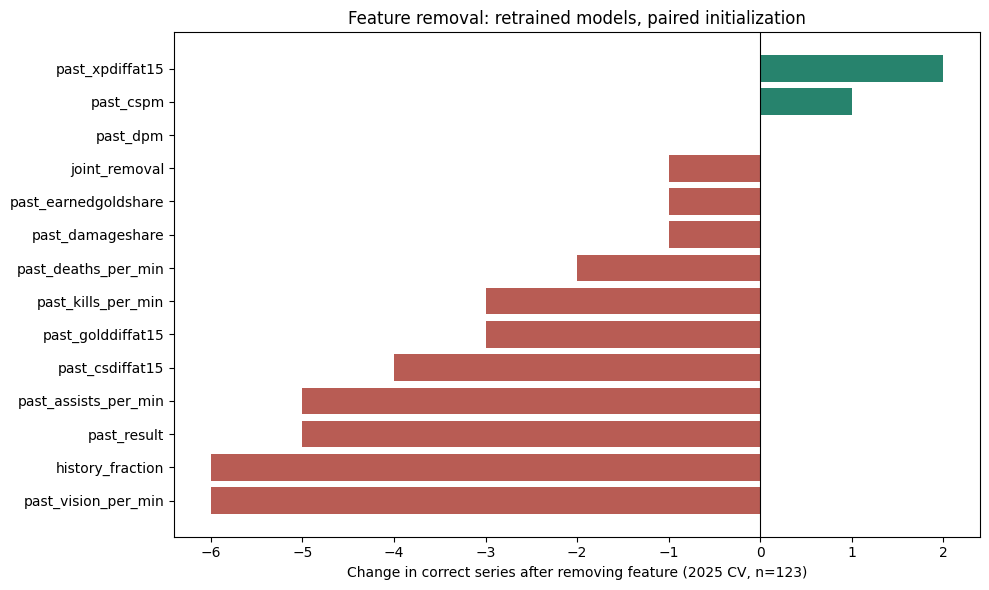

In [2]:
base = features.loc[features.candidate.eq('all13'),'correct'].iloc[0]
f = features[features.candidate.ne('all13')].sort_values('correct').copy()
fig, ax = plt.subplots(figsize=(10,6))
d = f.correct-base
ax.barh(f.candidate.str.replace('without_','',regex=False), d, color=['#27836d' if v>0 else '#b85c54' for v in d])
ax.axvline(0,color='black',linewidth=.8)
ax.set_xlabel('Change in correct series after removing feature (2025 CV, n=123)')
ax.set_title('Feature removal: retrained models, paired initialization')
fig.tight_layout()
fig.savefig(RESULTS/'feature_removal.png',dpi=160)
plt.show()

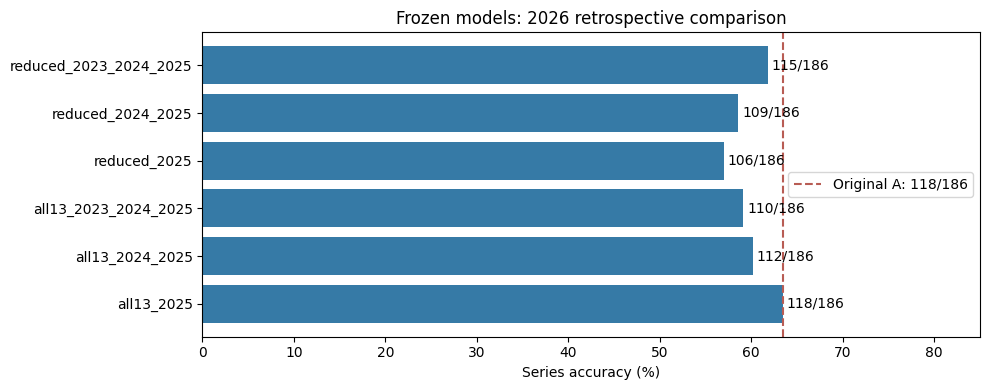

In [3]:
fig, ax = plt.subplots(figsize=(10,4))
ax.barh(evaluation.candidate, evaluation.accuracy*100,color='#367aa6')
ax.axvline(118/186*100,color='#b85c54',linestyle='--',label='Original A: 118/186')
for i,r in enumerate(evaluation.itertuples()): ax.text(r.accuracy*100+.4,i,f'{r.correct}/186',va='center')
ax.set_xlim(0,85)
ax.set_xlabel('Series accuracy (%)')
ax.set_title('Frozen models: 2026 retrospective comparison')
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS/'history_comparison.png',dpi=160)
plt.show()